## Loss Functions Implementation

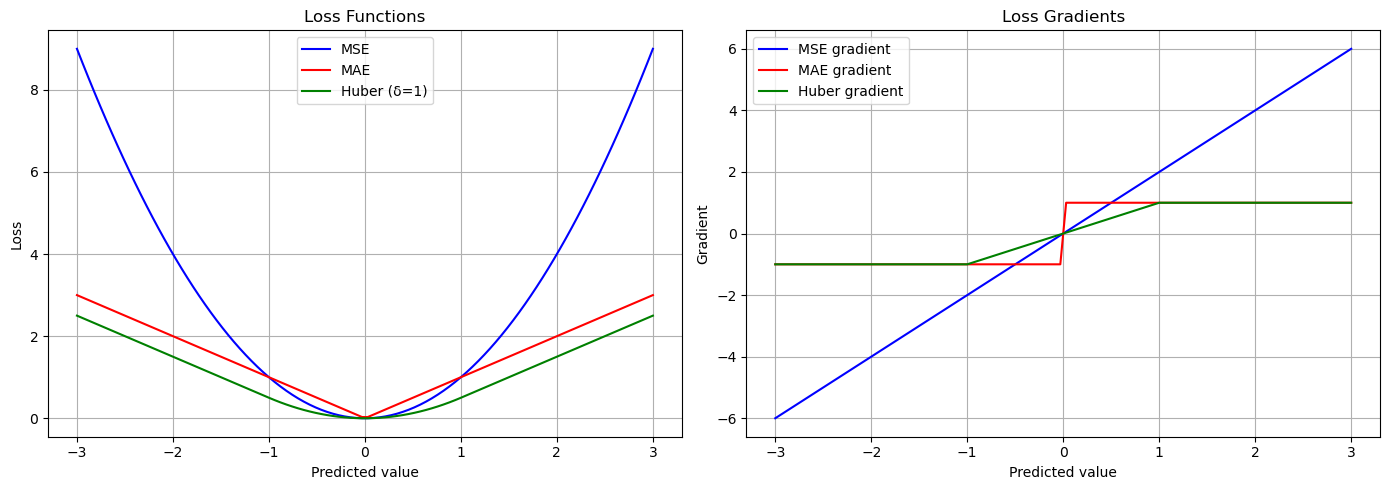

In [1]:
# importing the libraries
import numpy as np
import matplotlib.pyplot as plt

# true value
y_true = 0.0
y_pred = np.linspace(-3, 3, 100)
errors = y_true - y_pred

# mse
mse = errors ** 2

# mae
mae = np.abs(errors)

# huber
delta = 1.0
huber = np.where(np.abs(errors) <= delta,
                 0.5 * errors**2,
                 delta * np.abs(errors) - 0.5 * delta**2)

# plotting the losses
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(y_pred, mse, label='MSE', color='blue')
axes[0].plot(y_pred, mae, label='MAE', color='red')
axes[0].plot(y_pred, huber, label='Huber (δ=1)', color='green')
axes[0].set_title('Loss Functions')
axes[0].set_xlabel('Predicted value')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# plotting the gradients
mse_grad = -2 * errors
mae_grad = -np.sign(errors)
huber_grad = np.where(np.abs(errors) <= delta,
                      -errors,
                      -delta * np.sign(errors))

axes[1].plot(y_pred, mse_grad, label='MSE gradient', color='blue')
axes[1].plot(y_pred, mae_grad, label='MAE gradient', color='red')
axes[1].plot(y_pred, huber_grad, label='Huber gradient', color='green')
axes[1].set_title('Loss Gradients')
axes[1].set_xlabel('Predicted value')
axes[1].set_ylabel('Gradient')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [2]:
# softmax and categorical cross entropy

def softmax(z):

    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

def categorical_cross_entropy(y_true_onehot, y_pred_probs):
    return -np.mean(np.sum(y_true_onehot * np.log(y_pred_probs + 1e-8), axis=1))

# testing with 3 classes
raw_scores = np.array([[2.1, 0.5, 3.2],
                        [1.0, 4.2, 0.3],
                        [0.5, 0.5, 0.5]])

probs = softmax(raw_scores)
print("Raw scores:")
print(raw_scores)
print("\nAfter softmax:")
print(probs)
print("\nEach row sums to:", probs.sum(axis=1))

# one-hot true labels
y_true = np.array([[0, 0, 1],
                   [0, 1, 0],
                   [1, 0, 0]])

loss = categorical_cross_entropy(y_true, probs)
print(f"\nCategorical cross entropy loss: {loss:.4f}")

Raw scores:
[[2.1 0.5 3.2]
 [1.  4.2 0.3]
 [0.5 0.5 0.5]]

After softmax:
[[0.23775205 0.04800131 0.71424664]
 [0.03841852 0.94250341 0.01907807]
 [0.33333333 0.33333333 0.33333333]]

Each row sums to: [1. 1. 1.]

Categorical cross entropy loss: 0.4981
